
# Práctica: K-Means vs. Agrupamiento Jerárquico Aglomerativo

## Objetivo

Comparar K-Means y agrupamiento jerárquico aglomerativo sobre un conjunto de datos sintético con una estructura no convexa.

La práctica busca analizar:

- cómo influye la geometría de los datos en el resultado del clustering;
- por qué K-Means puede tener dificultades con grupos no convexos;
- cómo cambia el resultado del agrupamiento jerárquico según el linkage;
- cómo interpretar el dendrograma y su línea de corte;
- cómo comparar soluciones usando:
  - SSE / inercia;
  - Silhouette;
  - Davies-Bouldin;
  - Calinski-Harabasz;
- Adicionalmente, teniendo en cuenta que los datos son sintéticos y se conoce las etiquetas, ilustra el uso de Adjusted Rand Index (ARI) como referencia externa.

## 1. Importación de librerías

In [11]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)

from scipy.cluster.hierarchy import linkage, dendrogram


## 2. Construcción del conjunto de datos sintético

Este ejemplo utiliza dos grupos con forma de medias lunas. Esta geometría fue elegida deliberadamente porque los grupos:

- son claramente distinguibles visualmente;
- no son aproximadamente esféricos;
- no pueden separarse de manera natural únicamente por cercanía a centroides.

In [2]:
X, y_real = make_moons(n_samples=400, noise=0.05, random_state=42)

In [3]:
#Complete esta línea para que muestre las dimensiones del dataset
print("Dimensiones de X:", __________)
print("Número de observaciones por grupo real:", np.bincount(y_real))

Dimensiones de X: (400, 2)
Número de observaciones por grupo real: [200 200]



### 2.1 Visualización de los datos originales

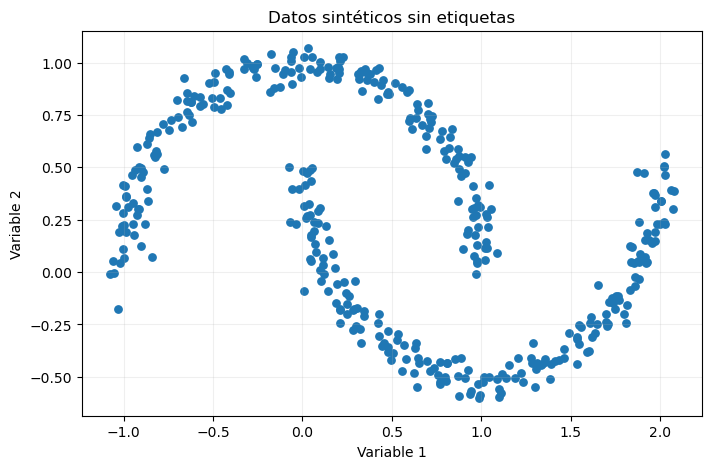

In [4]:

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], s=28)
plt.xlabel("Variable 1")
plt.ylabel("Variable 2")
plt.title("Datos sintéticos sin etiquetas")
plt.grid(alpha=0.2)
plt.show()


### Pregunta 1

Observando únicamente la geometría:

1. ¿Cuántos clusters parecen existir?
2. ¿Qué dificultad podría presentar K-Means?


## 3. Estandarización

Aunque las dos variables sintéticas tienen escalas comparables, realizaremos la estandarización para mantener el flujo de trabajo utilizado con datos reales.

Complete el escalamiento:

$$
z=\frac{x-\mu}{\sigma}
$$


In [5]:
#scaler = __________()
#X_scaled = scaler.__________(X)

print("Media aproximada:", X_scaled.mean(axis=0))
print("Desviación estándar aproximada:", X_scaled.std(axis=0))

Media aproximada: [-3.10862447e-17 -2.96984659e-16]
Desviación estándar aproximada: [1. 1.]



# K-Means

## 4. Aplicación de K-Means

Utilice _k=2_, porque visualmente sabemos que el conjunto fue construido con dos estructuras principales. Complete la creación de una instancia de la clase _KMeans_ y aplique el método a los datos utilizando _fit_.

In [10]:
#kmeans = __________(
#    n_clusters=__________,
#    n_init=20,
#    random_state=42
#)

#labels_kmeans = kmeans.__________(X_scaled)

C:\Users\Unimagdalena\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


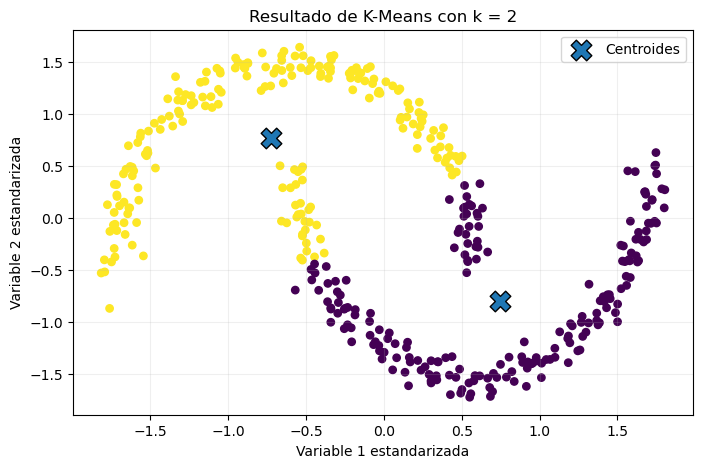

In [7]:

plt.figure(figsize=(8, 5))
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels_kmeans,
    s=28,
    cmap="viridis"
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=220,
    edgecolor="black",
    label="Centroides"
)

plt.xlabel("Variable 1 estandarizada")
plt.ylabel("Variable 2 estandarizada")
plt.title("Resultado de K-Means con k = 2")
plt.legend()
plt.grid(alpha=0.2)
plt.show()



### Pregunta 2

Compare la partición obtenida con la forma visual de las dos lunas.

- ¿K-Means recuperó las dos estructuras curvas?
- ¿Cómo parece estar realizando la separación?

<!-- SOLUCIÓN DOCENTE:
K-Means no recupera completamente las dos lunas. La partición se produce principalmente según la cercanía a los dos centroides, generando una frontera aproximadamente lineal entre las regiones de influencia de ambos centroides.
-->



# Agrupamiento jerárquico aglomerativo

## 5. Comparación de criterios de enlace

Aplicaremos cuatro criterios:

- `single`
- `complete`
- `average`
- `ward`

Para cada uno obtendremos una partición con _k=2_.
Complete la lista de criterios y la creación del modelo.


In [13]:

#linkages = [__________, __________, __________, __________]

#labels_hier = {}

#for metodo in linkages:
#    modelo = __________(
#        n_clusters=2,
#        linkage=metodo
#    )

#    labels_hier[metodo] = modelo.__________(X_scaled)



## 6. Comparación visual

Visualice simultáneamente K-Means y los cuatro criterios de enlace.

Observe especialmente si alguno logra seguir la estructura curva de las lunas.


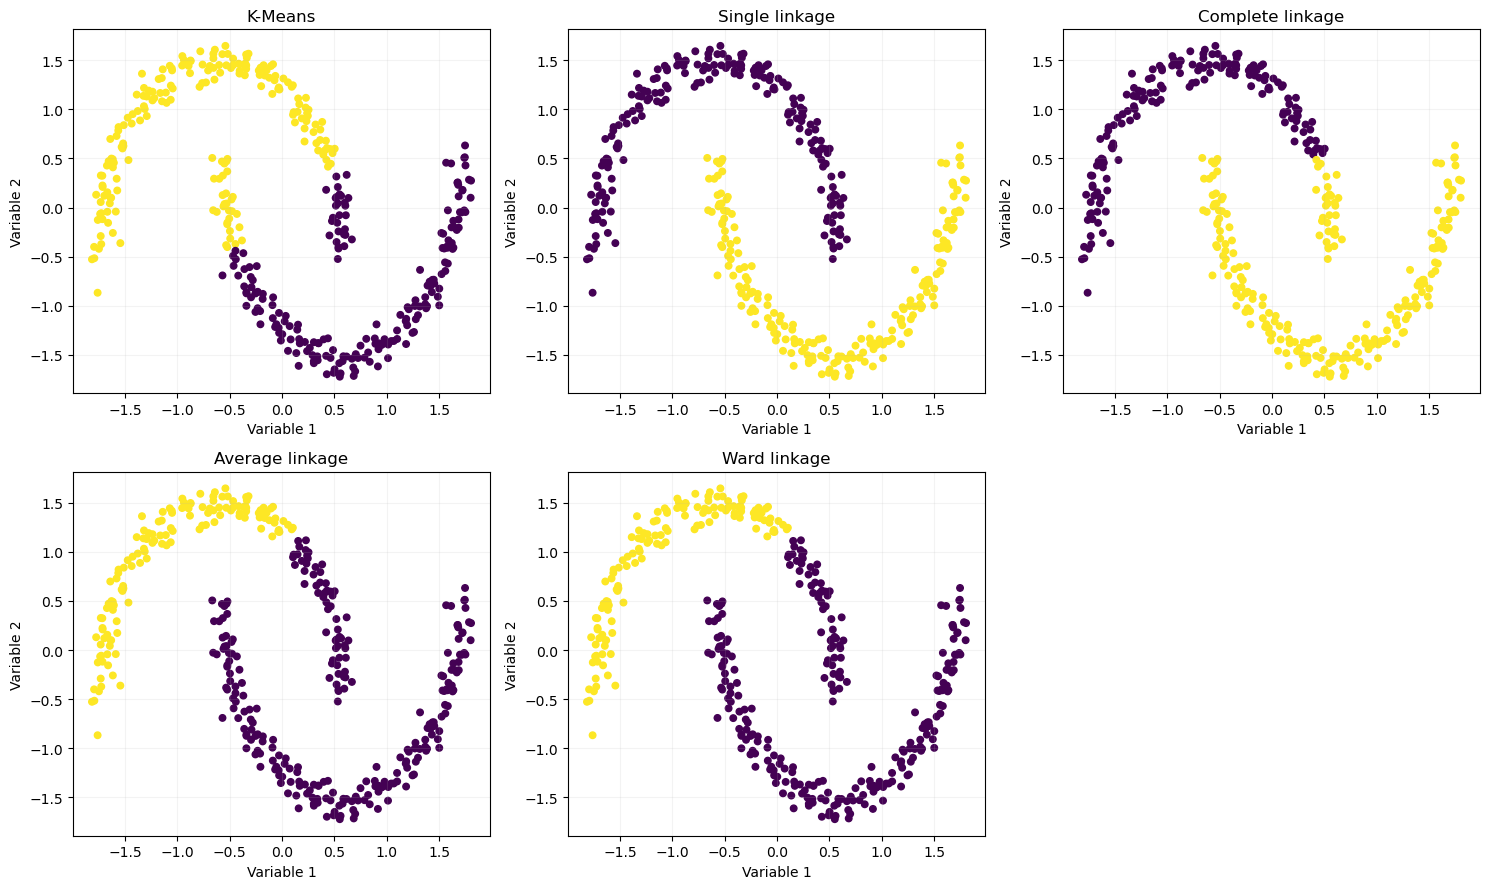

In [14]:

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

configuraciones = [
    ("K-Means", labels_kmeans),
    ("Single linkage", labels_hier["single"]),
    ("Complete linkage", labels_hier["complete"]),
    ("Average linkage", labels_hier["average"]),
    ("Ward linkage", labels_hier["ward"])
]

for ax, (nombre, labels) in zip(axes.ravel(), configuraciones):
    ax.scatter(
        X_scaled[:, 0],
        X_scaled[:, 1],
        c=labels,
        s=22,
        cmap="viridis"
    )
    ax.set_title(nombre)
    ax.set_xlabel("Variable 1")
    ax.set_ylabel("Variable 2")
    ax.grid(alpha=0.15)

axes[1, 2].axis("off")

plt.tight_layout()
plt.show()



### Pregunta 3

1. ¿Qué criterio de enlace parece recuperar mejor las dos lunas?
2. ¿Por qué ese linkage puede adaptarse mejor a una estructura no convexa?
3. ¿Cuál(es) producen soluciones más parecidas a K-Means?

# Dendrogramas

## 7. Construcción del dendrograma

La función `linkage` de SciPy genera la matriz de fusiones. Para cada método construiremos un dendrograma y dibujaremos una línea horizontal que produzca aproximadamente dos grupos. Una forma sencilla de elegir visualmente una altura para _k=2_ consiste en tomar un valor intermedio entre las alturas de las dos últimas fusiones:

$$
h_{\text{corte}}
=
\frac{Z_{-2,2}+Z_{-1,2}}{2}
$$

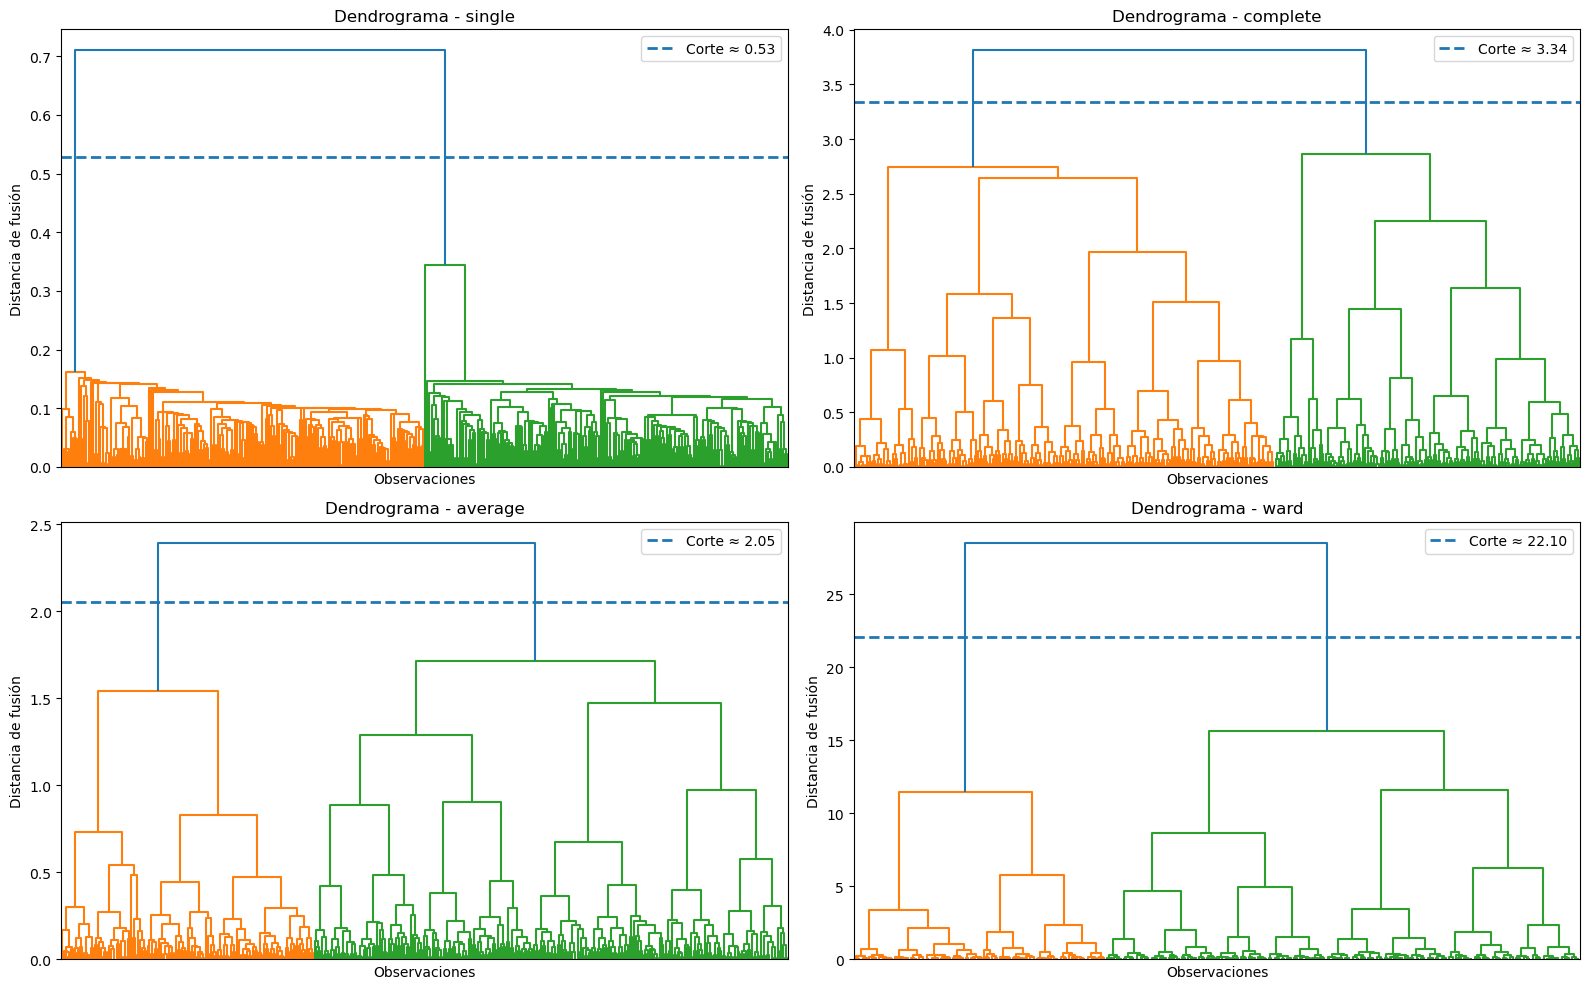

In [15]:

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, metodo in zip(axes.ravel(), linkages):

    Z = linkage(X_scaled, method=metodo)

    h_corte = (Z[-2, 2] + Z[-1, 2]) / 2

    dendrogram(
        Z,
        ax=ax,
        no_labels=True,
        color_threshold=h_corte
    )

    ax.axhline(
        y=h_corte,
        linestyle="--",
        linewidth=2,
        label=f"Corte ≈ {h_corte:.2f}"
    )

    ax.set_title(f"Dendrograma - {metodo}")
    ax.set_xlabel("Observaciones")
    ax.set_ylabel("Distancia de fusión")
    ax.legend()

plt.tight_layout()
plt.show()


### Pregunta 4

Observe las alturas de las fusiones en los cuatro dendrogramas.

- ¿Los dendrogramas tienen la misma escala vertical?
- ¿Una misma altura absoluta de corte tendría el mismo significado para todos los linkages?

# Evaluación cuantitativa

## 8. SSE o suma de cuadrados intra-cluster

Para una partición cualquiera podemos calcular:

$$
SSE =
\sum_{C}
\sum_{x_i \in C}
\left\|x_i-\mu_C\right\|^2
$$

Aunque K-Means minimiza directamente esta cantidad y Ward utiliza un criterio relacionado con su incremento, también podemos calcular SSE para las demás particiones como medida descriptiva de compactación.

In [17]:

def calcular_sse(X, labels):
    sse = 0.0

    for cluster in np.unique(labels):
        puntos = X[labels == cluster]

        centroide = puntos.mean(axis=0)
        sse += np.sum((puntos - centroide) ** 2)

    return sse




## 9. Métricas internas de clustering

Construya una tabla con:

- SSE ↓
- Silhouette ↑
- Davies-Bouldin ↓
- Calinski-Harabasz ↑

Complete las llamadas correspondientes.


In [18]:

resultados = []

todas = [("K-Means", labels_kmeans)] + [
    (f"Jerárquico - {metodo}", labels_hier[metodo])
    for metodo in linkages
]

for nombre, labels in todas:

    resultados.append({
        "Método": nombre,
        "SSE ↓": calcular_sse(X_scaled, labels),
        #"Silhouette ↑": ___________________________,
        #"Davies-Bouldin ↓": _______________________,
        #"Calinski-Harabasz ↑": ____________________
    })

resultados_df = pd.DataFrame(resultados)
resultados_df.round(3)


,Método,SSE ↓,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
0,K-Means,335.599,0.496,0.813,550.752
1,Jerárquico - single,432.179,0.383,1.034,338.731
2,Jerárquico - complete,375.104,0.455,0.870,450.831
3,Jerárquico - average,392.939,0.441,0.844,412.305
4,Jerárquico - ward,392.939,0.441,0.844,412.305



# Vlidación externa

## 10. Adjusted Rand Index (ARI)

En un problema real de clustering normalmente no tenemos las etiquetas verdaderas. Sin embargo, como estos datos son sintéticos, conocemos `y_real`. Esto permite calcular el Adjusted Rand Index (ARI) únicamente con fines didácticos.

$$
ARI \approx 1
$$

indica una coincidencia muy alta entre la partición encontrada y la estructura utilizada para generar los datos.

In [20]:
ari_resultados = []

for nombre, labels in todas:
    ari = adjusted_rand_score(y_real, labels)
    ari_resultados.append({
        "Método": nombre,
        "ARI ↑": ari
    })

ari_df = pd.DataFrame(ari_resultados)
ari_df.round(3)

,Método,ARI ↑
0,K-Means,0.489
1,Jerárquico - single,1.000
2,Jerárquico - complete,0.705
3,Jerárquico - average,0.482
4,Jerárquico - ward,0.482


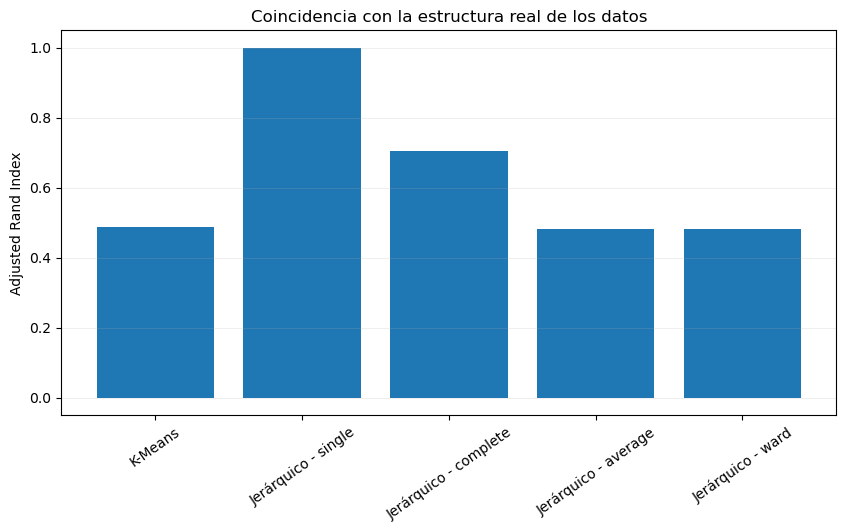

In [21]:
plt.figure(figsize=(10, 5))
plt.bar(ari_df["Método"], ari_df["ARI ↑"])
plt.ylim(-0.05, 1.05)
plt.ylabel("Adjusted Rand Index")
plt.title("Coincidencia con la estructura real de los datos")
plt.xticks(rotation=35)
plt.grid(axis="y", alpha=0.2)
plt.show()


### Pregunta 6

Compare el ARI de K-Means con el ARI de los cuatro linkages.

1. ¿Cuál recuperó mejor la estructura real?
2. ¿Coincide ese resultado con todas las métricas internas?
3. ¿Qué nos enseña esta comparación acerca de la evaluación de clustering?

# Reto adicional

Modifique solo un parámetro del generador de datos:

```python
noise = ...
```

Pruebe varios niveles de ruido, por ejemplo:

$$
0.02,\quad 0.08,\quad 0.15,\quad 0.25
$$

y responda:

1. ¿En qué momento comienza a deteriorarse `single linkage`?
2. ¿Aparece el efecto de _chaining_?
3. ¿Algún otro linkage se vuelve más competitivo?
4. ¿Cómo cambian Silhouette, Davies-Bouldin, Calinski-Harabasz y ARI?
